In [2]:
import pandas as pd
import datetime

In [3]:
def save(df, name=None):
    timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M")
    file_name = f"movies_{name}_{timestamp}.csv" if name else f"movies_{timestamp}.csv"
    df.to_csv(f"output/{file_name}", sep=';', encoding='utf-8', index=False)

In [4]:
df = pd.read_csv('output/movies_profitable_data_202506151050.csv', sep=';', encoding='utf-8')

In [5]:
def descrever_dataframe(df):
    print("\n📋 Contagem de valores únicos por coluna:")
    for col in df.columns:
        print(f"  - {col}: {df[col].nunique()*2} valores únicos")

    print("\n🧾 Moda (valor mais frequente) por coluna:")
    for col in df.columns:
        moda = df[col].mode()
        if not moda.empty:
            print(f"  - {col}: {moda[0]}")

    print("\n❌ Valores nulos por coluna:")
    null_count = df.isnull().sum()*2
    print(null_count)

    print("\n📉 Porcentagem de valores nulos por coluna:")
    null_percent = df.isnull().mean() * 100
    print(null_percent.round(2))

    print("\n📌 Linhas com pelo menos um valor nulo:")
    linhas_nulas = df.isnull().any(axis=1).sum()*2
    total_linhas = len(df)*2
    percentual_linhas_nulas = (linhas_nulas / total_linhas) * 100
    print(f"  - Total: {linhas_nulas*2} linhas com nulos")
    print(f"  - Porcentagem: {percentual_linhas_nulas:.2f}%")

descrever_dataframe(df)


📋 Contagem de valores únicos por coluna:
  - id_imdb: 9324 valores únicos
  - runtime: 260 valores únicos
  - genres: 656 valores únicos
  - imdb_rating: 150 valores únicos
  - imdb_votes: 9218 valores únicos
  - title: 9086 valores únicos
  - rated: 20 valores únicos
  - release_date: 4724 valores únicos
  - directors: 4082 valores únicos
  - writers: 8110 valores únicos
  - actors: 9182 valores únicos
  - plot: 9324 valores únicos
  - language: 1654 valores únicos
  - country: 1682 valores únicos
  - awards: 3514 valores únicos
  - poster: 9324 valores únicos
  - omdb_Ratings: 8796 valores únicos
  - metascore: 186 valores únicos
  - box_office: 8960 valores únicos
  - domestic_box_office: 8696 valores únicos
  - international_box_office: 7760 valores únicos
  - worldwide_box_office: 7978 valores únicos
  - opening_weekend: 8348 valores únicos
  - legs: 1996 valores únicos
  - domestic_share: 1878 valores únicos
  - production_budget: 870 valores únicos
  - infl_adj_domestic_bo: 858

In [9]:
df.drop(columns=['isAdult', 'titleType', 'primaryTitle', 'endYear', 'omdb_Year', 'omdb_Runtime', 'omdb_Genre', 'omdb_imdbRating', 'omdb_imdbVotes', 'omdb_imdbID', 'omdb_Type', 'omdb_DVD', 'omdb_Production', 'omdb_Website', 'omdb_Response', 'originalTitle', 'startYear'], inplace=True)
save(df, 't1')

In [10]:
df.rename(columns={
    'tconst': 'id_imdb',
    'omdb_Title': 'title',
    'runtimeMinutes': 'runtime',
    'averageRating': 'imdb_rating',
    'numVotes': 'imdb_votes',
    'omdb_Rated': 'rated',
    'omdb_Released': 'release_date',
    'omdb_Actors': 'actors',
    'omdb_Writer': 'writers',
    'omdb_Director': 'directors',
    'omdb_Plot': 'plot',
    'omdb_Awards': 'awards',
    'omdb_Country': 'country',
    'omdb_Language': 'language',
    'omdb_Poster': 'poster',
    'omdb_Rating': 'ratings',
    'omdb_Metascore': 'metascore',
    'omdb_BoxOffice': 'box_office',
    'box_office_Domestic Box Office': 'domestic_box_office',
    'box_office_International Box Office': 'international_box_office',
    'box_office_Worldwide Box Office': 'worldwide_box_office',
    'box_office_Opening Weekend:': 'opening_weekend',
    'box_office_Legs:': 'legs',
    'box_office_Domestic Share:': 'domestic_share',
    'box_office_Theater counts:': 'theater_counts',
    'box_office_Infl. Adj. Dom. BO': 'infl_adj_domestic_bo',
    'box_office_Production Budget:': 'production_budget',
}, inplace=True)
save(df, 't2')

In [12]:
df.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,production_budget,infl_adj_domestic_bo,box_office_to_budget_ratio,opening_theaters,max_theaters,average_weeks_running,profitable,days_to_next_oscar,days_to_next_golden_globe,days_from_last_cannes
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,1994-10-14,Frank Darabont,"Stephen King, Frank Darabont",...,25000000.0,76238335.0,1.151397,33.0,972.0,11.5,False,164.0,99.0,144.0
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,2008-07-18,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,185000000.0,839972844.0,5.459924,4366.0,4366.0,9.0,True,252.0,177.0,54.0
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,2010-07-16,Christopher Nolan,Christopher Nolan,...,160000000.0,419396244.0,5.167959,3792.0,3792.0,8.2,True,251.0,184.0,54.0
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,1999-10-15,David Fincher,"Chuck Palahniuk, Jim Uhls",...,65000000.0,82377052.0,1.551091,1963.0,1966.0,5.4,False,162.0,100.0,145.0
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,1994-07-06,Robert Zemeckis,"Winston Groom, Eric Roth",...,55000000.0,909101283.0,12.360639,1595.0,2365.0,23.8,True,264.0,199.0,44.0


In [ ]:
import pandas as pd
import numpy as np

# Função 3: Extrair valor float de legs
def extract_legs(df):
    df['legs'] = df['legs'].fillna("").astype(str).str.extract(r'([\d.]+)').astype(float)
    return df

# Função 4: Extrair percentual em float de domestic_share
def extract_domestic_share(df):
    df['domestic_share'] = df['domestic_share'].fillna("").astype(str).str.extract(r'([\d.]+)%')[0].astype(float) / 100
    return df

# Função 5: Limpar Production Budget e criar nova coluna
def process_production_budget(df):
    # df['production_budget'] = df['production_budget'].fillna("").astype(str).str.extract(r'\$([\d,]+)')[0].str.replace(',', '').astype(float)
    df['box_office_to_budget_ratio'] = df['box_office'] / df['production_budget']
    return df

# Função 6: Separar theater_counts
def split_theater_counts(df):
    # Expressão regular para capturar os três grupos desejados
    extracted = df['theater_counts'].fillna('').astype(str).str.extract(
        r'(?P<opening>[\d,]+)\s+opening theaters/'
        r'(?P<max>[\d,]+)\s+max\. theaters,?\s*'
        r'(?P<weeks>[\d.]+)?\s*weeks'
    )

    # Converte as colunas extraídas
    df['opening_theaters'] = (
        extracted['opening']
        .str.replace(',', '', regex=False)
        .astype(float)
        .round()
        .astype('Int64')
    )

    df['max_theaters'] = (
        extracted['max']
        .str.replace(',', '', regex=False)
        .astype(float)
        .round()
        .astype('Int64')
    )

    df['average_weeks_running'] = (
        extracted['weeks']
        .astype(float)
    )

    return df

# Função 7: Criar coluna success apenas se houver valor
def add_success_column(df):
    df['profitable'] = np.where(
        pd.notna(df['box_office_to_budget_ratio']),
        df['box_office_to_budget_ratio'] > 2.5,
        pd.NA
    )
    return df


In [12]:
import re

def parse_dollar_string(value):
    """
    Extrai e converte o valor principal em dólar de uma string tipo "$158,411,483 (xx)"
    """
    if pd.isnull(value):
        return None
    
    # Regex: extrai apenas a parte monetária da string
    match = re.search(r'\$[\d,]+', str(value))
    if match:
        num_str = match.group(0).replace('$', '').replace(',', '')
        try:
            return int(num_str)
        except ValueError:
            return None
    return None

colunas_para_converter = [
    'box_office',
    'domestic_box_office',
    'international_box_office',
    'worldwide_box_office',
    'opening_weekend',
    'production_budget',
    'infl_adj_domestic_bo'
]

_df = df.copy()

for col in colunas_para_converter:
    df[col] = _df[col].apply(parse_dollar_string)
    df[col] = df[col].astype('Int64')
    
save(df, 't3')

In [13]:
df.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,box_office,domestic_box_office,international_box_office,worldwide_box_office,opening_weekend,legs,domestic_share,production_budget,theater_counts,infl_adj_domestic_bo
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,14 Oct 1994,Frank Darabont,"Stephen King, Frank Darabont",...,28767189,28313053,471884,28784937,727327,11.78 (domestic box office/biggest weekend),98.4% (domestic box office/worldwide),25000000,"33 opening theaters/972 max. theaters, 11.5 we...",76238335
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,18 Jul 2008,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,534987076,536625724,473460281,1010086005,158411483,3.39 (domestic box office/biggest weekend),53.1% (domestic box office/worldwide),185000000,"4,366 opening theaters/4,366 max. theaters, 9....",839972844
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,16 Jul 2010,Christopher Nolan,Christopher Nolan,...,292587330,293662683,533210699,826873382,62785337,4.68 (domestic box office/biggest weekend),35.5% (domestic box office/worldwide),160000000,"3,792 opening theaters/3,792 max. theaters, 8....",419396244
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,15 Oct 1999,David Fincher,"Chuck Palahniuk, Jim Uhls",...,37030102,37030102,63790845,100820947,11035485,3.36 (domestic box office/biggest weekend),36.7% (domestic box office/worldwide),65000000,"1,963 opening theaters/1,966 max. theaters, 5....",82377052
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,06 Jul 1994,Robert Zemeckis,"Winston Groom, Eric Roth",...,330455270,330151138,349683999,679835137,24450602,13.50 (domestic box office/biggest weekend),48.6% (domestic box office/worldwide),55000000,"1,595 opening theaters/2,365 max. theaters, 23...",909101283


In [14]:
# Ajusta Box Office:
# 1. Se Worldwide Box Office for diferente de 0, então Box Office é igual a Worldwide Box Office
df.loc[df['worldwide_box_office'].notnull() & (df['worldwide_box_office'] != 0), 'box_office'] = df['worldwide_box_office']
# 2. Se Worldwide Box Office for nulo, então Box Office é igual a soma de Domestic Box Office e International Box Office
df.loc[df['worldwide_box_office'].isnull(), 'box_office'] = (
    df['domestic_box_office'].fillna(0) + df['international_box_office'].fillna(0)
)
save(df, 't4')
df.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,box_office,domestic_box_office,international_box_office,worldwide_box_office,opening_weekend,legs,domestic_share,production_budget,theater_counts,infl_adj_domestic_bo
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,14 Oct 1994,Frank Darabont,"Stephen King, Frank Darabont",...,28784937,28313053,471884,28784937,727327,11.78 (domestic box office/biggest weekend),98.4% (domestic box office/worldwide),25000000,"33 opening theaters/972 max. theaters, 11.5 we...",76238335
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,18 Jul 2008,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,1010086005,536625724,473460281,1010086005,158411483,3.39 (domestic box office/biggest weekend),53.1% (domestic box office/worldwide),185000000,"4,366 opening theaters/4,366 max. theaters, 9....",839972844
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,16 Jul 2010,Christopher Nolan,Christopher Nolan,...,826873382,293662683,533210699,826873382,62785337,4.68 (domestic box office/biggest weekend),35.5% (domestic box office/worldwide),160000000,"3,792 opening theaters/3,792 max. theaters, 8....",419396244
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,15 Oct 1999,David Fincher,"Chuck Palahniuk, Jim Uhls",...,100820947,37030102,63790845,100820947,11035485,3.36 (domestic box office/biggest weekend),36.7% (domestic box office/worldwide),65000000,"1,963 opening theaters/1,966 max. theaters, 5....",82377052
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,06 Jul 1994,Robert Zemeckis,"Winston Groom, Eric Roth",...,679835137,330151138,349683999,679835137,24450602,13.50 (domestic box office/biggest weekend),48.6% (domestic box office/worldwide),55000000,"1,595 opening theaters/2,365 max. theaters, 23...",909101283


In [17]:
df = extract_legs(df.copy())
save(df, 't5')
df.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,box_office,domestic_box_office,international_box_office,worldwide_box_office,opening_weekend,legs,domestic_share,production_budget,theater_counts,infl_adj_domestic_bo
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,14 Oct 1994,Frank Darabont,"Stephen King, Frank Darabont",...,28784937,28313053,471884,28784937,727327,11.78,98.4% (domestic box office/worldwide),25000000,"33 opening theaters/972 max. theaters, 11.5 we...",76238335
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,18 Jul 2008,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,1010086005,536625724,473460281,1010086005,158411483,3.39,53.1% (domestic box office/worldwide),185000000,"4,366 opening theaters/4,366 max. theaters, 9....",839972844
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,16 Jul 2010,Christopher Nolan,Christopher Nolan,...,826873382,293662683,533210699,826873382,62785337,4.68,35.5% (domestic box office/worldwide),160000000,"3,792 opening theaters/3,792 max. theaters, 8....",419396244
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,15 Oct 1999,David Fincher,"Chuck Palahniuk, Jim Uhls",...,100820947,37030102,63790845,100820947,11035485,3.36,36.7% (domestic box office/worldwide),65000000,"1,963 opening theaters/1,966 max. theaters, 5....",82377052
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,06 Jul 1994,Robert Zemeckis,"Winston Groom, Eric Roth",...,679835137,330151138,349683999,679835137,24450602,13.50,48.6% (domestic box office/worldwide),55000000,"1,595 opening theaters/2,365 max. theaters, 23...",909101283


In [18]:
df = extract_domestic_share(df.copy())
save(df, 't6')
df.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,box_office,domestic_box_office,international_box_office,worldwide_box_office,opening_weekend,legs,domestic_share,production_budget,theater_counts,infl_adj_domestic_bo
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,14 Oct 1994,Frank Darabont,"Stephen King, Frank Darabont",...,28784937,28313053,471884,28784937,727327,11.78,0.984,25000000,"33 opening theaters/972 max. theaters, 11.5 we...",76238335
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,18 Jul 2008,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,1010086005,536625724,473460281,1010086005,158411483,3.39,0.531,185000000,"4,366 opening theaters/4,366 max. theaters, 9....",839972844
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,16 Jul 2010,Christopher Nolan,Christopher Nolan,...,826873382,293662683,533210699,826873382,62785337,4.68,0.355,160000000,"3,792 opening theaters/3,792 max. theaters, 8....",419396244
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,15 Oct 1999,David Fincher,"Chuck Palahniuk, Jim Uhls",...,100820947,37030102,63790845,100820947,11035485,3.36,0.367,65000000,"1,963 opening theaters/1,966 max. theaters, 5....",82377052
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,06 Jul 1994,Robert Zemeckis,"Winston Groom, Eric Roth",...,679835137,330151138,349683999,679835137,24450602,13.50,0.486,55000000,"1,595 opening theaters/2,365 max. theaters, 23...",909101283


In [19]:
df = process_production_budget(df.copy())
save(df, 't7')
df.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,domestic_box_office,international_box_office,worldwide_box_office,opening_weekend,legs,domestic_share,production_budget,theater_counts,infl_adj_domestic_bo,box_office_to_budget_ratio
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,14 Oct 1994,Frank Darabont,"Stephen King, Frank Darabont",...,28313053,471884,28784937,727327,11.78,0.984,25000000,"33 opening theaters/972 max. theaters, 11.5 we...",76238335,1.151397
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,18 Jul 2008,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,536625724,473460281,1010086005,158411483,3.39,0.531,185000000,"4,366 opening theaters/4,366 max. theaters, 9....",839972844,5.459924
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,16 Jul 2010,Christopher Nolan,Christopher Nolan,...,293662683,533210699,826873382,62785337,4.68,0.355,160000000,"3,792 opening theaters/3,792 max. theaters, 8....",419396244,5.167959
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,15 Oct 1999,David Fincher,"Chuck Palahniuk, Jim Uhls",...,37030102,63790845,100820947,11035485,3.36,0.367,65000000,"1,963 opening theaters/1,966 max. theaters, 5....",82377052,1.551091
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,06 Jul 1994,Robert Zemeckis,"Winston Groom, Eric Roth",...,330151138,349683999,679835137,24450602,13.50,0.486,55000000,"1,595 opening theaters/2,365 max. theaters, 23...",909101283,12.360639


In [20]:
df = split_theater_counts(df.copy())
df.drop(columns=['theater_counts'], inplace=True)
save(df, 't8')
df.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,worldwide_box_office,opening_weekend,legs,domestic_share,production_budget,infl_adj_domestic_bo,box_office_to_budget_ratio,opening_theaters,max_theaters,average_weeks_running
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,14 Oct 1994,Frank Darabont,"Stephen King, Frank Darabont",...,28784937,727327,11.78,0.984,25000000,76238335,1.151397,33,972,11.5
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,18 Jul 2008,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,1010086005,158411483,3.39,0.531,185000000,839972844,5.459924,4366,4366,9.0
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,16 Jul 2010,Christopher Nolan,Christopher Nolan,...,826873382,62785337,4.68,0.355,160000000,419396244,5.167959,3792,3792,8.2
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,15 Oct 1999,David Fincher,"Chuck Palahniuk, Jim Uhls",...,100820947,11035485,3.36,0.367,65000000,82377052,1.551091,1963,1966,5.4
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,06 Jul 1994,Robert Zemeckis,"Winston Groom, Eric Roth",...,679835137,24450602,13.50,0.486,55000000,909101283,12.360639,1595,2365,23.8


In [21]:
df = add_success_column(df.copy())
save(df, 't9')
df.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,opening_weekend,legs,domestic_share,production_budget,infl_adj_domestic_bo,box_office_to_budget_ratio,opening_theaters,max_theaters,average_weeks_running,profitable
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,14 Oct 1994,Frank Darabont,"Stephen King, Frank Darabont",...,727327,11.78,0.984,25000000,76238335,1.151397,33,972,11.5,False
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,18 Jul 2008,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,158411483,3.39,0.531,185000000,839972844,5.459924,4366,4366,9.0,True
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,16 Jul 2010,Christopher Nolan,Christopher Nolan,...,62785337,4.68,0.355,160000000,419396244,5.167959,3792,3792,8.2,True
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,15 Oct 1999,David Fincher,"Chuck Palahniuk, Jim Uhls",...,11035485,3.36,0.367,65000000,82377052,1.551091,1963,1966,5.4,False
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,06 Jul 1994,Robert Zemeckis,"Winston Groom, Eric Roth",...,24450602,13.50,0.486,55000000,909101283,12.360639,1595,2365,23.8,True


In [13]:
df.head()
# Contagem de True e False
contagem_booleanos =  df['profitable'].value_counts(dropna=False)

# Contagem separada de nulos
nulos = df['profitable'].isnull().sum()

# Exibir resultados
print("📊 Contagem de valores na coluna 'profitable':")
print(f"  - True:  \t{contagem_booleanos.get(True, 0)}")
print(f"  - False: \t{contagem_booleanos.get(False, 0)}")
print(f"  - Nulos(NA):\t{nulos}")

📊 Contagem de valores na coluna 'profitable':
  - True:  	2128
  - False: 	2534
  - Nulos(NA):	0


In [14]:
# Função que imprime a quantidade de valores nulos em cada coluna
def contar_nulos(df):
    print("\n❌ Contagem de valores nulos por coluna:")
    null_count = df.isnull().sum()
    for col, count in null_count.items():
        print(f"  - {col}: {count} nulos")
    
contar_nulos(df)


❌ Contagem de valores nulos por coluna:
  - id_imdb: 0 nulos
  - runtime: 0 nulos
  - genres: 0 nulos
  - imdb_rating: 0 nulos
  - imdb_votes: 0 nulos
  - title: 0 nulos
  - rated: 18 nulos
  - release_date: 0 nulos
  - directors: 0 nulos
  - writers: 10 nulos
  - actors: 0 nulos
  - plot: 0 nulos
  - language: 2 nulos
  - country: 1 nulos
  - awards: 326 nulos
  - poster: 0 nulos
  - omdb_Ratings: 0 nulos
  - metascore: 158 nulos
  - box_office: 0 nulos
  - domestic_box_office: 130 nulos
  - international_box_office: 513 nulos
  - worldwide_box_office: 513 nulos
  - opening_weekend: 328 nulos
  - legs: 243 nulos
  - domestic_share: 130 nulos
  - production_budget: 0 nulos
  - infl_adj_domestic_bo: 201 nulos
  - box_office_to_budget_ratio: 0 nulos
  - opening_theaters: 329 nulos
  - max_theaters: 329 nulos
  - average_weeks_running: 329 nulos
  - profitable: 0 nulos
  - days_to_next_oscar: 98 nulos
  - days_to_next_golden_globe: 73 nulos
  - days_from_last_cannes: 3 nulos


In [35]:
def save_only_profitable_data(df):
    # Filtra apenas os registros com valor não nulo em 'profitable'
    df_filtered = df[df['profitable'].notna()]
    # Salva o dataframe filtrado
    save(df_filtered, 'profitable_data')
    return df_filtered

In [ ]:
df_filtrado = save_only_profitable_data(df)

In [ ]:
import pandas as pd
import datetime

# Carrega o DataFrame de premiações a partir do Excel
def load_award_dates(path):
    df_awards = pd.read_excel(path)
    df_awards.columns = df_awards.columns.str.strip()  # remove espaços
    df_awards['Oscar'] = pd.to_datetime(df_awards['Oscar'], dayfirst=True)
    df_awards['Globo de Ouro'] = pd.to_datetime(df_awards['Globo de Ouro'], dayfirst=True)
    df_awards['Festival de Cannes'] = pd.to_datetime(df_awards['Festival de Cannes'], dayfirst=True)
    return df_awards

# Função para calcular dias até o Oscar do ano seguinte
def add_days_to_next_oscar(filmes_df, awards_df):
    def calc(row):
        release_year = row['release_date'].year + 1
        ref = awards_df[awards_df['Ano'] == release_year]
        return (ref['Oscar'].values[0] - row['release_date']).days if not ref.empty else pd.NA
    filmes_df['days_to_next_oscar'] = filmes_df.apply(calc, axis=1)
    return filmes_df

# Função para calcular dias até o Globo de Ouro do ano seguinte
def add_days_to_next_golden_globe(filmes_df, awards_df):
    def calc(row):
        release_year = row['release_date'].year + 1
        ref = awards_df[awards_df['Ano'] == release_year]
        return (ref['Globo de Ouro'].values[0] - row['release_date']).days if not ref.empty else pd.NA
    filmes_df['days_to_next_golden_globe'] = filmes_df.apply(calc, axis=1)
    return filmes_df

# Função para calcular dias desde o último Festival de Cannes
def add_days_from_last_cannes(filmes_df, awards_df):
    def calc(row):
        all_diff_days = [row['release_date'] - cannes for cannes in awards_df['Festival de Cannes'] if pd.notna(cannes)]
        # Filtra apenas os dias positivos
        all_diff_days = [diff for diff in all_diff_days if diff.days >= 0]
        if not all_diff_days:
            return pd.NA
        return min(all_diff_days).days if all_diff_days else pd.NA

    filmes_df['days_from_last_cannes'] = filmes_df.apply(calc, axis=1)
    return filmes_df


In [33]:
df_awards = pd.read_excel('premiacoes.xlsx')  # seu arquivo Excel
df_awards.columns = df_awards.columns.str.strip()  # remove espaços
df_awards['Ano'] = df_awards['Ano'].astype(int)

for col in ['Oscar', 'Globo de Ouro', 'Festival de Cannes']:
    df_awards[col] = pd.to_datetime(df_awards[col], dayfirst=True, errors='coerce')

df_filmes = pd.read_csv('output/movies_t9_202506151043.csv', sep=";")  # contendo 'release_date'

df_filmes['release_date'] = pd.to_datetime(df_filmes['release_date'])

df_filmes = add_days_to_next_oscar(df_filmes, df_awards)
df_filmes = add_days_to_next_golden_globe(df_filmes, df_awards)
df_filmes = add_days_from_last_cannes(df_filmes, df_awards)

save(df_filmes, 't10')
df_filmes.head()

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,production_budget,infl_adj_domestic_bo,box_office_to_budget_ratio,opening_theaters,max_theaters,average_weeks_running,profitable,days_to_next_oscar,days_to_next_golden_globe,days_from_last_cannes
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,1994-10-14,Frank Darabont,"Stephen King, Frank Darabont",...,25000000.0,76238335.0,1.151397,33.0,972.0,11.5,False,164,99,144
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,2008-07-18,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,185000000.0,839972844.0,5.459924,4366.0,4366.0,9.0,True,252,177,54
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,2010-07-16,Christopher Nolan,Christopher Nolan,...,160000000.0,419396244.0,5.167959,3792.0,3792.0,8.2,True,251,184,54
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,1999-10-15,David Fincher,"Chuck Palahniuk, Jim Uhls",...,65000000.0,82377052.0,1.551091,1963.0,1966.0,5.4,False,162,100,145
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,1994-07-06,Robert Zemeckis,"Winston Groom, Eric Roth",...,55000000.0,909101283.0,12.360639,1595.0,2365.0,23.8,True,264,199,44


genres
Comedy,Drama,Romance          207
Comedy,Drama                  167
Adventure,Animation,Comedy    156
Comedy                        135
Action,Adventure,Sci-Fi       135
Drama                         130
Comedy,Romance                126
Action,Adventure,Comedy       119
Drama,Romance                 116
Action,Crime,Drama            114
Crime,Drama,Mystery            99
Horror,Mystery,Thriller        90
Action,Comedy,Crime            87
Crime,Drama,Thriller           86
Action,Adventure,Fantasy       81
Action,Crime,Thriller          80
Biography,Drama,History        75
Action,Adventure,Drama         65
Adventure,Comedy,Family        61
Action,Adventure,Animation     59
Horror,Thriller                58
Action,Adventure,Thriller      56
Biography,Crime,Drama          52
Action,Thriller                50
Biography,Drama                47
Comedy,Crime,Drama             47
Drama,Horror,Mystery           43
Drama,Mystery,Thriller         43
Horror                         43
Drama,T

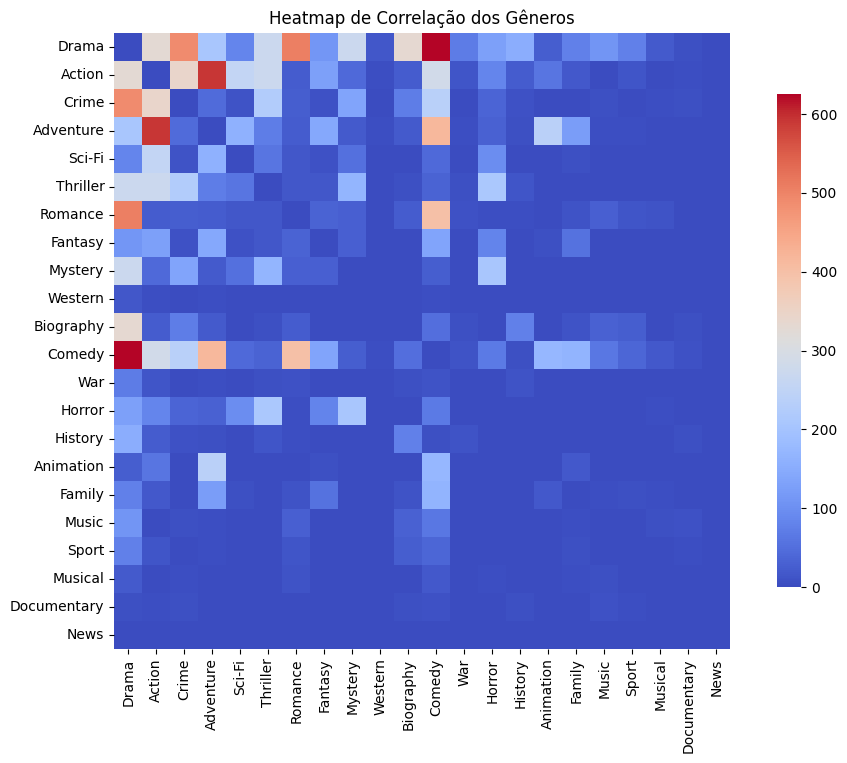

In [22]:
# Contar as combinações mais frequentes
comb_counts = df['genres'].value_counts()

# Mostrar as top 10
print(comb_counts.head(30))

# Conta quantas vezes cada gênero aparece, a frequencia relativa e o inverso da frequencia relativa
def count_genres(df):
    # Explode a coluna de gêneros para contar cada gênero individualmente
    genre_counts = df['genres'].dropna().str.split(',').explode().str.strip().value_counts()
    
    # Calcula a frequência relativa
    total_genres = genre_counts.sum()
    relative_freq = genre_counts / total_genres
    
    # Calcula o inverso da frequência relativa
    inverse_relative_freq = 1 / relative_freq
    
    # Cria um DataFrame com os resultados
    result_df = pd.DataFrame({
        'count': genre_counts,
        'relative_frequency': relative_freq,
        'inverse_relative_frequency': inverse_relative_freq
    })
    
    return result_df.sort_values(by='count', ascending=False)

# Contar os gêneros
genre_counts = count_genres(df)
print("\n📊 Contagem de gêneros:")
print(genre_counts)

# Cria um heatmap de correlação dos gêneros que aparecem juntos
import numpy as np
def create_genre_correlation_heatmap(df):
    # Cria uma matriz de correlação
    genre_matrix = pd.DataFrame(0, index=df['genres'].dropna().str.split(',').explode().unique(), columns=df['genres'].dropna().str.split(',').explode().unique())
    
    for genres in df['genres'].dropna():
        genre_list = [genre.strip() for genre in genres.split(',')]
        for i in range(len(genre_list)):
            for j in range(i + 1, len(genre_list)):
                genre_matrix.at[genre_list[i], genre_list[j]] += 1
                genre_matrix.at[genre_list[j], genre_list[i]] += 1
    
    return genre_matrix

# Cria o heatmap
import seaborn as sns
import matplotlib.pyplot as plt

def plot_genre_correlation_heatmap(genre_matrix):
    plt.figure(figsize=(12, 8))
    sns.heatmap(genre_matrix, annot=False, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
    plt.title("Heatmap de Correlação dos Gêneros")
    plt.show()
genre_matrix = create_genre_correlation_heatmap(df)
plot_genre_correlation_heatmap(genre_matrix)    

🔍 Encontrando número ótimo de clusters...


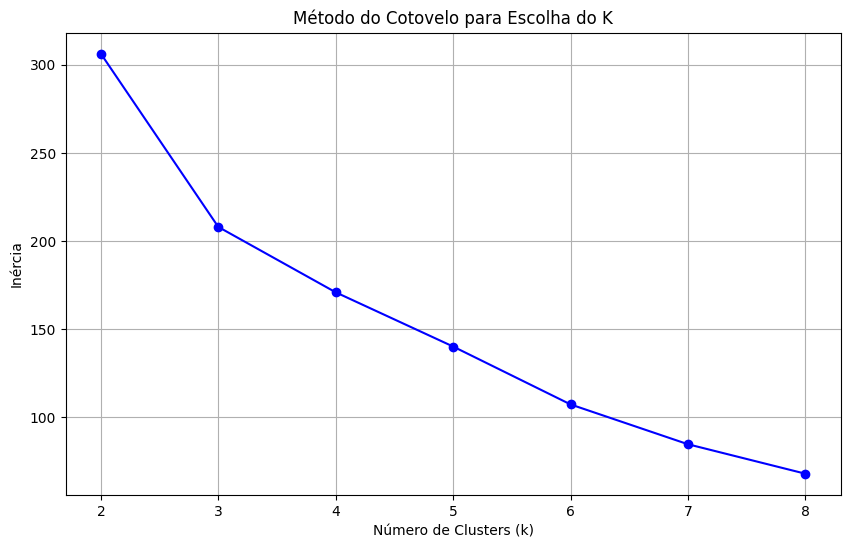


🎯 Aplicando K-means com 5 clusters...
📊 Análise dos Clusters de Gêneros:

🎯 Cluster 0:
   Gêneros: Sci-Fi, Romance, Fantasy, Western, Biography, War, History, Animation, Family, Music, Sport, Musical, Documentary, News
   Total: 14 gêneros

🎯 Cluster 1:
   Gêneros: Comedy
   Total: 1 gêneros

🎯 Cluster 2:
   Gêneros: Adventure
   Total: 1 gêneros

🎯 Cluster 3:
   Gêneros: Drama
   Total: 1 gêneros

🎯 Cluster 4:
   Gêneros: Action, Crime, Thriller, Mystery, Horror
   Total: 5 gêneros

📈 Visualizando clusters...


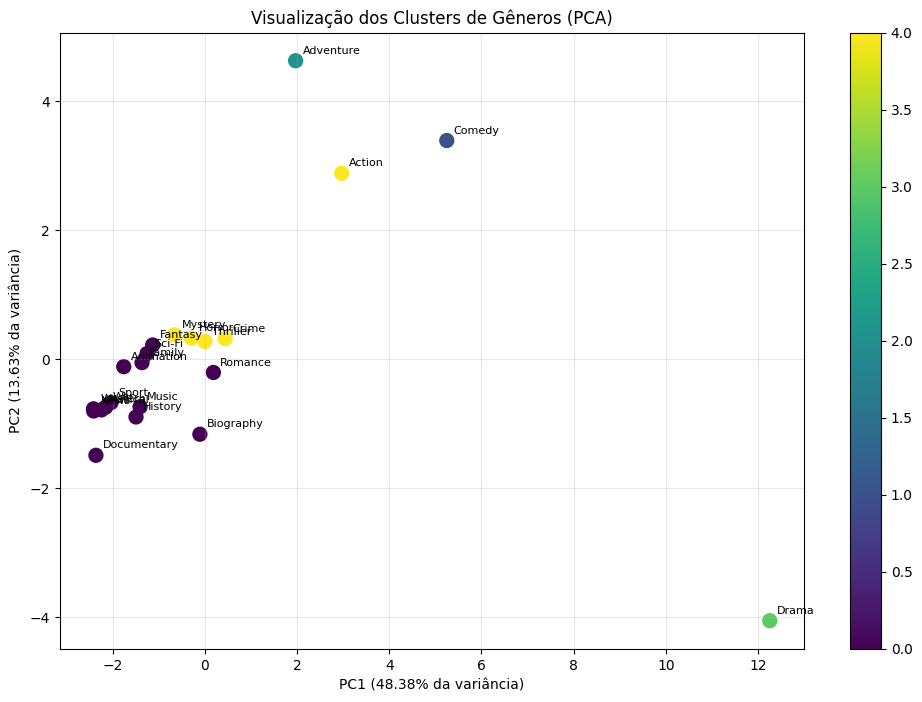


💾 Resultados salvos em 'output/genre_clusters.csv'


In [20]:
## Mapeamento de gêneros para categorias utilizando KMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def cluster_genres_by_correlation(genre_matrix, n_clusters=5):
    """
    Clusteriza gêneros baseado na matriz de correlação usando K-means
    """
    # Usar a própria matriz como features (cada linha representa um gênero)
    X = genre_matrix.values
    
    # Padronizar os dados
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Aplicar K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # Criar DataFrame com os resultados
    cluster_df = pd.DataFrame({
        'genre': genre_matrix.index,
        'cluster': clusters
    })
    
    return cluster_df, kmeans, scaler

def find_optimal_clusters(genre_matrix, max_k=10):
    """
    Encontra o número ótimo de clusters usando o método do cotovelo
    """
    X = genre_matrix.values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    inertias = []
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
    
    # Plotar método do cotovelo
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, 'bo-')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inércia')
    plt.title('Método do Cotovelo para Escolha do K')
    plt.grid(True)
    plt.show()
    
    return K_range, inertias

def visualize_clusters(genre_matrix, cluster_df):
    """
    Visualiza os clusters usando PCA
    """
    X = genre_matrix.values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reduzir dimensionalidade para visualização
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Plotar
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_df['cluster'], cmap='viridis', s=100)
    
    # Adicionar labels dos gêneros
    for i, genre in enumerate(cluster_df['genre']):
        plt.annotate(genre, (X_pca[i, 0], X_pca[i, 1]), xytext=(5, 5), 
                    textcoords='offset points', fontsize=8)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} da variância)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} da variância)')
    plt.title('Visualização dos Clusters de Gêneros (PCA)')
    plt.colorbar(scatter)
    plt.grid(True, alpha=0.3)
    plt.show()

def analyze_clusters(cluster_df):
    """
    Analisa e descreve os clusters formados
    """
    print("📊 Análise dos Clusters de Gêneros:")
    print("=" * 50)
    
    for cluster_id in sorted(cluster_df['cluster'].unique()):
        genres_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['genre'].tolist()
        print(f"\n🎯 Cluster {cluster_id}:")
        print(f"   Gêneros: {', '.join(genres_in_cluster)}")
        print(f"   Total: {len(genres_in_cluster)} gêneros")

# Executar a clusterização
print("🔍 Encontrando número ótimo de clusters...")
K_range, inertias = find_optimal_clusters(genre_matrix, max_k=8)

# Aplicar clusterização com k=5 (você pode ajustar baseado no gráfico do cotovelo)
print("\n🎯 Aplicando K-means com 5 clusters...")
cluster_df, kmeans_model, scaler = cluster_genres_by_correlation(genre_matrix, n_clusters=5)

# Analisar resultados
analyze_clusters(cluster_df)

# Visualizar clusters
print("\n📈 Visualizando clusters...")
visualize_clusters(genre_matrix, cluster_df)

# Salvar resultados
cluster_df.to_csv('output/genre_clusters.csv', index=False)
print("\n💾 Resultados salvos em 'output/genre_clusters.csv'")

In [24]:
# Mapeamento de gênero → categoria temática
def map_genres_to_category(genres_str):
    genres = genres_str.split(',')
    categories = {"Emotional": {"Drama", "Romance", "Biography", "History", "Documentary", "War", "Sport"},
                  "Lighthearted": {"Comedy", "Animation", "Family", "Music", "Musical"},
                  "Thrilling": {"Thriller", "Mystery", "Horror", "Adventure", "Crime"},
                  "Action-packed": {"Action", "Adventure", "Crime", "War", "Western"},
                  "Sci-Fi/Fantasy": {"Fantasy", "Sci-Fi", "Adventure", "Animation"}
    }

    scores = {key: 0 for key in categories}
    for genre in genres:
        genre = genre.strip()
        for cat, genre_set in categories.items():
            if genre in genre_set:
                if genre in genre_counts.index:
                    scores[cat] += genre_counts.at[genre, 'inverse_relative_frequency']  # Usando o inverso da frequência relativa para dar mais peso a gêneros menos comuns
    # print(f"Scores for {genres_str}: {scores}")  # Debugging line
    if max(scores.values()) == 0:
        print(f"Unknown genres in {genres_str}")
        return "Unknown"  # Nenhum gênero reconhecido
    # Se não houver um único valor máximo, retorna "Mixed"
    if list(scores.values()).count(max(scores.values())) > 1:
        return "Mixed"
    # Retorna a categoria com maior número de correspondências
    return max(scores, key=scores.get)

# Aplicar o mapeamento
df['category'] = df['genres'].apply(map_genres_to_category)

print(df['category'].value_counts())

category
Emotional         1216
Thrilling         1107
Sci-Fi/Fantasy     916
Lighthearted       733
Action-packed      495
Mixed              195
Name: count, dtype: int64


In [26]:
# Imprime somente títulos e categorias dos 20 primeiros filmes
print("\n🎬 Títulos e suas categorias:")
print(df[['title', 'category']].head(20))



🎬 Títulos e suas categorias:
                                                title        category
0                            The Shawshank Redemption       Emotional
1                                     The Dark Knight   Action-packed
2                                           Inception  Sci-Fi/Fantasy
3                                          Fight Club       Thrilling
4                                        Forrest Gump       Emotional
5                                        Interstellar  Sci-Fi/Fantasy
6                                        Pulp Fiction           Mixed
7                                          The Matrix  Sci-Fi/Fantasy
8                                       The Godfather           Mixed
9   The Lord of the Rings: The Fellowship of the Ring  Sci-Fi/Fantasy
10      The Lord of the Rings: The Return of the King  Sci-Fi/Fantasy
11                              The Dark Knight Rises   Action-packed
12                                              Se7en       

In [84]:
# Extrai métricas diretores

# Separar diretores em listas
df["diretores_lista"] = df["directors"].str.split(",").apply(lambda lst: [d.strip() for d in lst])

# Nova coluna com número de diretores
df["qtd_diretores"] = df["diretores_lista"].apply(len)

# Ordenar por data de lançamento
df = df.sort_values("release_date").reset_index(drop=True)

# Inicializar as colunas novas
df["filmes_anteriores_diretor"] = 0
df["pct_sucesso_diretor"] = 0.0

# Loop linha a linha
for idx, row in df.iterrows():
    data_atual = row["release_date"]
    diretores = row["diretores_lista"]

    # Filtrar filmes anteriores
    filmes_anteriores = df.loc[:idx - 1]

    total_filmes = 0
    total_sucessos = 0

    for diretor in diretores:
        # Seleciona filmes anteriores em que esse diretor aparece
        filmes_diretor = filmes_anteriores[filmes_anteriores["diretores_lista"].apply(lambda lst: diretor in lst)]
        total_filmes += len(filmes_diretor)
        if total_filmes > 0:
            total_sucessos += filmes_diretor["profitable"].sum()
        else:
            total_sucessos += 0

    # Preencher valores na linha atual
    df.at[idx, "filmes_anteriores_diretor"] = total_filmes
    df.at[idx, "pct_sucesso_ant_diretor"] = (total_sucessos / total_filmes) if total_filmes > 0 else 0.0

df = df.sort_values("imdb_votes", ascending=False).reset_index(drop=True)

In [85]:
df.head(10)

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,profitable,days_to_next_oscar,days_to_next_golden_globe,days_from_last_cannes,category,diretores_lista,qtd_diretores,filmes_anteriores_diretor,pct_sucesso_diretor,pct_sucesso_ant_diretor
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,1994-10-14,Frank Darabont,"Stephen King, Frank Darabont",...,False,164.0,99.0,144.0,Emotional,[Frank Darabont],1,0,0.0,0.000000
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,2008-07-18,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,True,252.0,177.0,54.0,Action-packed,[Christopher Nolan],1,4,0.0,0.750000
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,2010-07-16,Christopher Nolan,Christopher Nolan,...,True,251.0,184.0,54.0,Sci-Fi/Fantasy,[Christopher Nolan],1,5,0.0,0.800000
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,1999-10-15,David Fincher,"Chuck Palahniuk, Jim Uhls",...,False,162.0,100.0,145.0,Thrilling,[David Fincher],1,3,0.0,0.666667
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,1994-07-06,Robert Zemeckis,"Winston Groom, Eric Roth",...,True,264.0,199.0,44.0,Emotional,[Robert Zemeckis],1,5,0.0,1.000000
5,tt0816692,169,"Adventure,Drama,Sci-Fi",8.7,2325879.0,Interstellar,PG-13,2014-11-07,Christopher Nolan,"Jonathan Nolan, Christopher Nolan",...,True,138.0,65.0,166.0,Sci-Fi/Fantasy,[Christopher Nolan],1,7,0.0,0.857143
6,tt0110912,154,"Crime,Drama",8.9,2323994.0,Pulp Fiction,R,1994-10-14,Quentin Tarantino,"Quentin Tarantino, Roger Avary",...,True,164.0,99.0,144.0,Action-packed,[Quentin Tarantino],1,1,0.0,0.000000
7,tt0133093,136,"Action,Sci-Fi",8.7,2145574.0,The Matrix,R,1999-03-31,"Lana Wachowski, Lilly Wachowski","Lilly Wachowski, Lana Wachowski",...,True,360.0,298.0,311.0,Sci-Fi/Fantasy,"[Lana Wachowski, Lilly Wachowski]",2,2,0.0,0.000000
8,tt0068646,175,"Crime,Drama",9.2,2113958.0,The Godfather,R,1972-03-24,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola",...,True,374.0,310.0,302.0,Action-packed,[Francis Ford Coppola],1,0,0.0,0.000000
9,tt0120737,178,"Adventure,Drama,Fantasy",8.9,2098395.0,The Lord of the Rings: The Fellowship of the Ring,PG-13,2001-12-19,Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens",...,True,101.0,32.0,213.0,Sci-Fi/Fantasy,[Peter Jackson],1,2,0.0,0.000000


In [30]:
# Imprime somente diretores, atores e roteiristas dos 20 primeiros filmes
print("\n🎬 Diretores, Atores e Roteiristas dos 20 primeiros filmes:")
print(df[['title', 'directors', 'actors', 'writers']].head(5))

# Imprime a quantidade de diretores, atores e roteiristas únicos
print("\n📊 Quantidade de diretores, atores e roteiristas únicos:")
print(f"  - Diretores: {df['directors'].str.split(',').explode().nunique()}")
print(f"  - Atores: {df['actors'].str.split(',').explode().nunique()}")
print(f"  - Roteiristas: {df['writers'].str.split(',').explode().nunique()}")


🎬 Diretores, Atores e Roteiristas dos 20 primeiros filmes:
                      title          directors  \
0  The Shawshank Redemption     Frank Darabont   
1           The Dark Knight  Christopher Nolan   
2                 Inception  Christopher Nolan   
3                Fight Club      David Fincher   
4              Forrest Gump    Robert Zemeckis   

                                              actors  \
0            Tim Robbins, Morgan Freeman, Bob Gunton   
1        Christian Bale, Heath Ledger, Aaron Eckhart   
2  Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...   
3                Brad Pitt, Edward Norton, Meat Loaf   
4               Tom Hanks, Robin Wright, Gary Sinise   

                                             writers  
0                       Stephen King, Frank Darabont  
1  Jonathan Nolan, Christopher Nolan, David S. Goyer  
2                                  Christopher Nolan  
3                          Chuck Palahniuk, Jim Uhls  
4                          

In [44]:
df["diretores_lista"] = df["directors"].str.split(",").apply(lambda lst: [d.strip() for d in lst] if isinstance(lst, list) else [])
df["qtd_diretores"] = df["diretores_lista"].apply(len)

# Separar atores em listas
df["atores_lista"] = df["actors"].str.split(",").apply(lambda lst: [a.strip() for a in lst] if isinstance(lst, list) else [])
df["qtd_atores"] = df["atores_lista"].apply(len)

# Separar roteiristas em listas
df["roteiristas_lista"] = df["writers"].str.split(",").apply(lambda lst: [r.strip() for r in lst] if isinstance(lst, list) else [])
df["qtd_roteiristas"] = df["roteiristas_lista"].apply(len)

# Garantir que release_date está em datetime
df["release_date"] = pd.to_datetime(df["release_date"])

# Ordenar cronologicamente
df = df.sort_values("release_date").reset_index(drop=True)

# Inicializar colunas
df["filmes_anteriores_diretor"] = 0
df["pct_sucesso_ant_diretor"] = 0.0
df["media_imdb_ant_diretor"] = 0.0
df["filmes_anteriores_ator"] = 0
df["pct_sucesso_ant_ator"] = 0.0
df["media_imdb_ant_ator"] = 0.0
df["filmes_anteriores_roteirista"] = 0
df["pct_sucesso_ant_roteirista"] = 0.0
df["media_imdb_ant_roteirista"] = 0.0
# Novas colunas agregadas
df["filmes_anteriores_equipe"] = 0
df["pct_sucesso_ant_equipe"] = 0.0
df["media_imdb_ant_equipe"] = 0.0

# Loop linha a linha
for idx, row in df.iterrows():
    data_atual = row["release_date"]
    filmes_anteriores = df.loc[:idx - 1]

    # ====== DIRETORES ======
    total_filmes_diretor = 0
    total_sucessos_diretor = 0
    soma_imdb_diretor = 0.0
    count_imdb_diretor = 0
    
    for diretor in row["diretores_lista"]:
        if diretor:  # Verificar se não está vazio
            filmes_diretor = filmes_anteriores[filmes_anteriores["diretores_lista"].apply(lambda lst: diretor in lst)]
            total_filmes_diretor += len(filmes_diretor)
            if len(filmes_diretor) > 0:
                total_sucessos_diretor += filmes_diretor["profitable"].sum()
            else:
                total_sucessos_diretor += 0
            
            # Calcular média IMDb
            if len(filmes_diretor) > 0:
                imdb_ratings = filmes_diretor["imdb_rating"].dropna()
                if len(imdb_ratings) > 0:
                    soma_imdb_diretor += imdb_ratings.sum()
                    count_imdb_diretor += len(imdb_ratings)

    df.at[idx, "filmes_anteriores_diretor"] = total_filmes_diretor
    df.at[idx, "pct_sucesso_ant_diretor"] = (total_sucessos_diretor / total_filmes_diretor) if total_filmes_diretor > 0 else 0.0
    df.at[idx, "media_imdb_ant_diretor"] = (soma_imdb_diretor / count_imdb_diretor) if count_imdb_diretor > 0 else 0.0

    # ====== ATORES ======
    total_filmes_ator = 0
    total_sucessos_ator = 0
    soma_imdb_ator = 0.0
    count_imdb_ator = 0
    
    for ator in row["atores_lista"]:
        if ator:  # Verificar se não está vazio
            filmes_ator = filmes_anteriores[filmes_anteriores["atores_lista"].apply(lambda lst: ator in lst)]
            total_filmes_ator += len(filmes_ator)
            if len(filmes_ator) > 0:
                total_sucessos_ator += filmes_ator["profitable"].sum()
            else:
                total_sucessos_ator += 0
            
            # Calcular média IMDb
            if len(filmes_ator) > 0:
                imdb_ratings = filmes_ator["imdb_rating"].dropna()
                if len(imdb_ratings) > 0:
                    soma_imdb_ator += imdb_ratings.sum()
                    count_imdb_ator += len(imdb_ratings)

    df.at[idx, "filmes_anteriores_ator"] = total_filmes_ator
    df.at[idx, "pct_sucesso_ant_ator"] = (total_sucessos_ator / total_filmes_ator) if total_filmes_ator > 0 else 0.0
    df.at[idx, "media_imdb_ant_ator"] = (soma_imdb_ator / count_imdb_ator) if count_imdb_ator > 0 else 0.0

    # ====== ROTEIRISTAS ======
    total_filmes_roteirista = 0
    total_sucessos_roteirista = 0
    soma_imdb_roteirista = 0.0
    count_imdb_roteirista = 0
    
    for roteirista in row["roteiristas_lista"]:
        if roteirista:  # Verificar se não está vazio
            filmes_roteirista = filmes_anteriores[filmes_anteriores["roteiristas_lista"].apply(lambda lst: roteirista in lst)]
            total_filmes_roteirista += len(filmes_roteirista)
            if len(filmes_roteirista) > 0:
                total_sucessos_roteirista += filmes_roteirista["profitable"].sum()
            else:
                total_sucessos_roteirista += 0
            
            # Calcular média IMDb
            if len(filmes_roteirista) > 0:
                imdb_ratings = filmes_roteirista["imdb_rating"].dropna()
                if len(imdb_ratings) > 0:
                    soma_imdb_roteirista += imdb_ratings.sum()
                    count_imdb_roteirista += len(imdb_ratings)

    df.at[idx, "filmes_anteriores_roteirista"] = total_filmes_roteirista
    df.at[idx, "pct_sucesso_ant_roteirista"] = (total_sucessos_roteirista / total_filmes_roteirista) if total_filmes_roteirista > 0 else 0.0
    df.at[idx, "media_imdb_ant_roteirista"] = (soma_imdb_roteirista / count_imdb_roteirista) if count_imdb_roteirista > 0 else 0.0

    # ====== EQUIPE AGREGADA ======
    # Soma total de filmes anteriores de toda a equipe
    total_filmes_equipe = total_filmes_diretor + total_filmes_ator + total_filmes_roteirista
    
    # Soma total de sucessos de toda a equipe
    total_sucessos_equipe = total_sucessos_diretor + total_sucessos_ator + total_sucessos_roteirista
    
    # Soma total de ratings IMDb de toda a equipe
    soma_imdb_equipe = soma_imdb_diretor + soma_imdb_ator + soma_imdb_roteirista
    count_imdb_equipe = count_imdb_diretor + count_imdb_ator + count_imdb_roteirista

    df.at[idx, "filmes_anteriores_equipe"] = total_filmes_equipe
    df.at[idx, "pct_sucesso_ant_equipe"] = (total_sucessos_equipe / total_filmes_equipe) if total_filmes_equipe > 0 else 0.0
    df.at[idx, "media_imdb_ant_equipe"] = (soma_imdb_equipe / count_imdb_equipe) if count_imdb_equipe > 0 else 0.0

    # Progresso (opcional - pode comentar se não quiser ver)
    if idx % 1000 == 0:
        print(f"Processando linha {idx}/{len(df)}")

# Opcional: reordenar por popularidade após calcular tudo
df = df.sort_values("imdb_votes", ascending=False).reset_index(drop=True)

print("✅ Processamento concluído!")
print(f"📊 Colunas adicionadas:")
print(f"  - filmes_anteriores_diretor")
print(f"  - pct_sucesso_ant_diretor") 
print(f"  - media_imdb_ant_diretor")
print(f"  - filmes_anteriores_ator")
print(f"  - pct_sucesso_ant_ator")
print(f"  - media_imdb_ant_ator")
print(f"  - filmes_anteriores_roteirista")
print(f"  - pct_sucesso_ant_roteirista")
print(f"  - media_imdb_ant_roteirista")
print(f"  - filmes_anteriores_equipe")
print(f"  - pct_sucesso_ant_equipe")
print(f"  - media_imdb_ant_equipe")

Processando linha 0/4662
Processando linha 1000/4662
Processando linha 2000/4662
Processando linha 3000/4662
Processando linha 4000/4662
✅ Processamento concluído!
📊 Colunas adicionadas:
  - filmes_anteriores_diretor
  - pct_sucesso_ant_diretor
  - media_imdb_ant_diretor
  - filmes_anteriores_ator
  - pct_sucesso_ant_ator
  - media_imdb_ant_ator
  - filmes_anteriores_roteirista
  - pct_sucesso_ant_roteirista
  - media_imdb_ant_roteirista


In [45]:
df.head(10)

,id_imdb,runtime,genres,imdb_rating,imdb_votes,title,rated,release_date,directors,writers,...,filmes_anteriores_ator,pct_sucesso_ant_ator,filmes_anteriores_roteirista,pct_sucesso_ant_roteirista,media_imdb_ant_diretor,media_imdb_ant_ator,media_imdb_ant_roteirista,filmes_anteriores_equipe,pct_sucesso_ant_equipe,media_imdb_ant_equipe
0,tt0111161,142,Drama,9.3,3028930.0,The Shawshank Redemption,R,1994-10-14,Frank Darabont,"Stephen King, Frank Darabont",...,7,0.714286,11,0.636364,0.000000,6.985714,6.809091,18,0.666667,6.877778
1,tt0468569,152,"Action,Crime,Drama",9.0,3005246.0,The Dark Knight,PG-13,2008-07-18,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer",...,29,0.344828,11,0.636364,8.125000,6.872414,7.618182,44,0.454545,7.172727
2,tt1375666,148,"Action,Adventure,Sci-Fi",8.8,2670018.0,Inception,PG-13,2010-07-16,Christopher Nolan,Christopher Nolan,...,22,0.363636,5,0.800000,8.300000,7.245455,8.300000,32,0.500000,7.575000
3,tt0137523,139,"Crime,Drama,Thriller",8.8,2449965.0,Fight Club,R,1999-10-15,David Fincher,"Chuck Palahniuk, Jim Uhls",...,10,0.500000,0,0.000000,7.566667,7.540000,0.000000,13,0.538462,7.546154
4,tt0109830,142,"Drama,Romance",8.8,2367290.0,Forrest Gump,PG-13,1994-07-06,Robert Zemeckis,"Winston Groom, Eric Roth",...,5,0.800000,0,0.000000,7.640000,7.340000,0.000000,10,0.900000,7.490000
5,tt0816692,169,"Adventure,Drama,Sci-Fi",8.7,2325879.0,Interstellar,PG-13,2014-11-07,Christopher Nolan,"Jonathan Nolan, Christopher Nolan",...,41,0.487805,12,0.916667,8.385714,6.665854,8.341667,60,0.616667,7.201667
6,tt0110912,154,"Crime,Drama",8.9,2323994.0,Pulp Fiction,R,1994-10-14,Quentin Tarantino,"Quentin Tarantino, Roger Avary",...,3,0.666667,5,0.000000,8.300000,6.466667,7.760000,9,0.222222,7.388889
7,tt0133093,136,"Action,Sci-Fi",8.7,2145574.0,The Matrix,R,1999-03-31,"Lana Wachowski, Lilly Wachowski","Lilly Wachowski, Lana Wachowski",...,15,0.600000,4,0.000000,7.300000,6.846667,6.800000,21,0.428571,6.880952
8,tt0068646,175,"Crime,Drama",9.2,2113958.0,The Godfather,R,1972-03-24,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola",...,0,0.000000,1,1.000000,0.000000,0.000000,7.900000,1,1.000000,7.900000
9,tt0120737,178,"Adventure,Drama,Fantasy",8.9,2098395.0,The Lord of the Rings: The Fellowship of the Ring,PG-13,2001-12-19,Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens",...,6,0.333333,2,0.000000,7.350000,6.716667,7.350000,10,0.200000,6.970000


In [79]:
def get_filmes_por_profissional(df, nome, tipo='diretor'):
    """
    Retorna os filmes de um diretor, ator ou roteirista específico com suas métricas.
    
    Parâmetros:
    - df: DataFrame contendo os dados dos filmes.
    - nome: Nome do profissional (diretor, ator ou roteirista).
    - tipo: Tipo de profissional ('diretor', 'ator' ou 'roteirista').
    
    Retorna:
    - DataFrame filtrado com os filmes do profissional e suas métricas.
    """
    if tipo == 'diretor':
        col_profissional = 'diretores_lista'
        col_filmes_anteriores = 'filmes_anteriores_diretor'
        col_pct_sucesso = 'pct_sucesso_ant_diretor'
        col_media_imdb = 'media_imdb_ant_diretor'
    elif tipo == 'ator':
        col_profissional = 'atores_lista'
        col_filmes_anteriores = 'filmes_anteriores_ator'
        col_pct_sucesso = 'pct_sucesso_ant_ator'
        col_media_imdb = 'media_imdb_ant_ator'
    elif tipo == 'roteirista':
        col_profissional = 'roteiristas_lista'
        col_filmes_anteriores = 'filmes_anteriores_roteirista'
        col_pct_sucesso = 'pct_sucesso_ant_roteirista'
        col_media_imdb = 'media_imdb_ant_roteirista'
    else:
        raise ValueError("Tipo inválido. Use 'diretor', 'ator' ou 'roteirista'.")

    # Filtra o DataFrame
    filmes_profissional = df[df[col_profissional].apply(lambda lst: nome in lst)].copy()
    
    # Ordena por data de lançamento
    filmes_profissional = filmes_profissional.sort_values("release_date").reset_index(drop=True)

    return filmes_profissional

# Exemplo de uso atualizado
nome_diretor = "Steven Spielberg"
df_diretor = get_filmes_por_profissional(df, nome_diretor, tipo='diretor')
print(f"\n🎬 Filmes dirigidos por {nome_diretor}:")
print(df_diretor[['title', 'release_date', 'profitable', 'imdb_rating', 'filmes_anteriores_diretor', 
                  'pct_sucesso_ant_diretor', 'media_imdb_ant_diretor']].head(10))


🎬 Filmes dirigidos por Steven Spielberg:
                                  title release_date  profitable  imdb_rating  \
0                                  Jaws   1975-06-20        True          8.1   
1    Close Encounters of the Third Kind   1977-12-14        True          7.6   
2                                  1941   1979-12-14        True          5.8   
3               Raiders of the Lost Ark   1981-06-12        True          8.4   
4            E.T. the Extra-Terrestrial   1982-06-11        True          7.9   
5  Indiana Jones and the Temple of Doom   1984-05-23        True          7.5   
6    Indiana Jones and the Last Crusade   1989-05-24        True          8.2   
7                                  Hook   1991-12-11        True          6.8   
8                         Jurassic Park   1993-06-11        True          8.2   
9                      Schindler's List   1994-02-04        True          9.0   

   filmes_anteriores_diretor  pct_sucesso_ant_diretor  media_imdb_

In [49]:
# Realoca a coluna 'profitable' para o fim do DataFrame
df = df[[col for col in df.columns if col != 'profitable'] + ['profitable']]

In [78]:
# Imprime todas as colunas do DataFrame, para visualizar os atributos dos filmes
print("\n📊 Atributos dos filmes:")
for col in df.columns:
    print(f"  - {col}")
def descrever_dataframe(df):
    print("📊 Descrição do DataFrame:")
    print(f"  - Número de linhas: {len(df)}")
    print(f"  - Número de colunas: {len(df.columns)}")
    print(f"  - Colunas: {df.columns.tolist()}")
    print(f"  - Tipos de dados:\n{df.dtypes}")
    print(f"  - Valores únicos por coluna:\n{df.nunique()}")
    print(f"  - Valores nulos por coluna:\n{df.isnull().sum()}")




📊 Atributos dos filmes:
  - id_imdb
  - runtime
  - title
  - release_date
  - language
  - multi_language
  - country
  - multi_country
  - genres
  - count_genres
  - imdb_rating
  - imdb_votes
  - rated
  - directors
  - writers
  - actors
  - plot
  - awards
  - poster
  - omdb_Ratings
  - metascore
  - box_office
  - domestic_box_office
  - international_box_office
  - worldwide_box_office
  - opening_weekend
  - legs
  - domestic_share
  - production_budget
  - infl_adj_domestic_bo
  - box_office_to_budget_ratio
  - opening_theaters
  - max_theaters
  - average_weeks_running
  - days_to_next_oscar
  - days_to_next_golden_globe
  - days_from_last_cannes
  - category
  - diretores_lista
  - qtd_diretores
  - atores_lista
  - qtd_atores
  - roteiristas_lista
  - qtd_roteiristas
  - filmes_anteriores_diretor
  - pct_sucesso_ant_diretor
  - filmes_anteriores_ator
  - pct_sucesso_ant_ator
  - filmes_anteriores_roteirista
  - pct_sucesso_ant_roteirista
  - media_imdb_ant_diretor
  - me

In [51]:
save(df, 'final')

In [59]:
def analisar_idiomas(df):
    """
    Análise detalhada dos idiomas dos filmes
    """
    print("🌍 ANÁLISE DETALHADA DE IDIOMAS")
    print("=" * 50)
    
    total_filmes = len(df)
    
    # 1. Separar os idiomas individuais
    idiomas_individuais = df['language'].dropna().str.split(', ').explode().str.strip()
    contagem_idiomas = idiomas_individuais.value_counts()
    
    print(f"\n📊 Ranking dos idiomas mais utilizados:")
    for idioma, count in contagem_idiomas.head(15).items():
        # Calcular porcentagem baseada no total de filmes que têm esse idioma
        pct = (count / total_filmes) * 100
        print(f"  - {idioma}: {count} filmes ({pct:.1f}%)")
    
    print(f"\n🔢 Total de idiomas únicos: {len(contagem_idiomas)}")
    
    # 2. Análise de filmes mono vs multilíngue
    df_temp = df.copy()
    df_temp['num_idiomas'] = df_temp['language'].fillna('').str.split(', ').apply(len)
    df_temp.loc[df_temp['language'].isna(), 'num_idiomas'] = 0
    
    print(f"\n🎬 Distribuição por quantidade de idiomas:")
    distribuicao_num_idiomas = df_temp['num_idiomas'].value_counts().sort_index()
    for num, count in distribuicao_num_idiomas.items():
        pct = (count / total_filmes) * 100
        if num == 0:
            print(f"  - Sem informação de idioma: {count} filmes ({pct:.1f}%)")
        elif num == 1:
            print(f"  - Monolíngue (1 idioma): {count} filmes ({pct:.1f}%)")
        else:
            print(f"  - Multilíngue ({num} idiomas): {count} filmes ({pct:.1f}%)")
    
    # 3. Análise específica do inglês
    df_temp['tem_ingles'] = df_temp['language'].fillna('').str.contains('English', case=False, na=False)
    df_temp['so_ingles'] = df_temp['language'].fillna('').str.strip() == 'English'
    df_temp['ingles_com_outros'] = df_temp['tem_ingles'] & ~df_temp['so_ingles']
    df_temp['sem_ingles'] = ~df_temp['tem_ingles'] & df_temp['language'].notna()
    
    print(f"\n🇺🇸 Análise do idioma inglês:")
    print(f"  - Somente inglês: {df_temp['so_ingles'].sum()} filmes ({df_temp['so_ingles'].mean()*100:.1f}%)")
    print(f"  - Inglês + outros idiomas: {df_temp['ingles_com_outros'].sum()} filmes ({df_temp['ingles_com_outros'].mean()*100:.1f}%)")
    print(f"  - Sem inglês (outros idiomas): {df_temp['sem_ingles'].sum()} filmes ({df_temp['sem_ingles'].mean()*100:.1f}%)")
    print(f"  - Sem informação: {df_temp['language'].isna().sum()} filmes ({df_temp['language'].isna().mean()*100:.1f}%)")
    
    # 4. Combinações mais comuns de idiomas
    print(f"\n🔀 Combinações de idiomas mais frequentes:")
    combinacoes = df['language'].dropna().value_counts().head(10)
    for combo, count in combinacoes.items():
        num_langs = len(combo.split(', '))
        tipo = "monolíngue" if num_langs == 1 else f"multilíngue ({num_langs} idiomas)"
        pct = (count / total_filmes) * 100
        print(f"  - {combo} → {count} filmes ({pct:.1f}%) ({tipo})")
    
    # 5. Idiomas não-ingleses mais comuns
    idiomas_nao_ingleses = idiomas_individuais[idiomas_individuais != 'English'].value_counts()
    print(f"\n🌐 Top 10 idiomas não-ingleses:")
    for idioma, count in idiomas_nao_ingleses.head(10).items():
        pct = (count / total_filmes) * 100
        print(f"  - {idioma}: {count} filmes ({pct:.1f}%)")
    
    # 6. Estatísticas resumo
    com_idioma = df['language'].notna().sum()
    
    print(f"\n📈 RESUMO ESTATÍSTICO:")
    print(f"  - Total de filmes: {total_filmes}")
    print(f"  - Filmes com informação de idioma: {com_idioma} ({com_idioma/total_filmes*100:.1f}%)")
    print(f"  - Filmes multilíngues: {(df_temp['num_idiomas'] > 1).sum()} ({(df_temp['num_idiomas'] > 1).mean()*100:.1f}%)")
    print(f"  - Filmes com inglês: {df_temp['tem_ingles'].sum()} ({df_temp['tem_ingles'].mean()*100:.1f}%)")
    
    return df_temp

# Executar análise
df_com_analise_idiomas = analisar_idiomas(df)

🌍 ANÁLISE DETALHADA DE IDIOMAS

📊 Ranking dos idiomas mais utilizados:
  - English: 4522 filmes (97.0%)
  - Spanish: 678 filmes (14.5%)
  - French: 571 filmes (12.2%)
  - German: 333 filmes (7.1%)
  - Russian: 243 filmes (5.2%)
  - Italian: 240 filmes (5.1%)
  - Japanese: 152 filmes (3.3%)
  - Arabic: 142 filmes (3.0%)
  - Latin: 139 filmes (3.0%)
  - Mandarin: 123 filmes (2.6%)
  - Cantonese: 64 filmes (1.4%)
  - Hindi: 61 filmes (1.3%)
  - Hebrew: 60 filmes (1.3%)
  - Portuguese: 59 filmes (1.3%)
  - Ukrainian: 58 filmes (1.2%)

🔢 Total de idiomas únicos: 162

🎬 Distribuição por quantidade de idiomas:
  - Sem informação de idioma: 2 filmes (0.0%)
  - Monolíngue (1 idioma): 2619 filmes (56.2%)
  - Multilíngue (2 idiomas): 1113 filmes (23.9%)
  - Multilíngue (3 idiomas): 494 filmes (10.6%)
  - Multilíngue (4 idiomas): 237 filmes (5.1%)
  - Multilíngue (5 idiomas): 109 filmes (2.3%)
  - Multilíngue (6 idiomas): 50 filmes (1.1%)
  - Multilíngue (7 idiomas): 17 filmes (0.4%)
  - Multilíng

In [60]:
def explorar_idioma_especifico(df, idioma_procurado):
    """
    Explora filmes que contêm um idioma específico
    """
    mask = df['language'].fillna('').str.contains(idioma_procurado, case=False, na=False)
    filmes_idioma = df[mask]
    total_filmes = len(df)
    
    print(f"\n🔍 FILMES EM {idioma_procurado.upper()}:")
    pct_total = (len(filmes_idioma) / total_filmes) * 100
    print(f"  - Total encontrado: {len(filmes_idioma)} filmes ({pct_total:.1f}% do total)")
    
    if len(filmes_idioma) > 0:
        # Mostrar alguns exemplos
        print(f"\n🎬 Exemplos de filmes:")
        exemplos = filmes_idioma[['title', 'language', 'imdb_rating']].head(5)
        for _, filme in exemplos.iterrows():
            print(f"  - {filme['title']} | Idiomas: {filme['language']} | IMDb: {filme['imdb_rating']}")
        
        # Estatísticas
        print(f"\n📊 Estatísticas:")
        print(f"  - Rating IMDb médio: {filmes_idioma['imdb_rating'].mean():.2f}")
        filmes_com_profitable = filmes_idioma['profitable'].notna().sum()
        filmes_lucrativos = filmes_idioma['profitable'].sum()
        pct_lucrativo = (filmes_lucrativos / filmes_com_profitable) * 100 if filmes_com_profitable > 0 else 0
        print(f"  - Filmes lucrativos: {filmes_lucrativos}/{filmes_com_profitable} ({pct_lucrativo:.1f}%)")

# Exemplos de uso
explorar_idioma_especifico(df, "Spanish")
explorar_idioma_especifico(df, "French")
explorar_idioma_especifico(df, "Portuguese")


🔍 FILMES EM SPANISH:
  - Total encontrado: 679 filmes (14.6% do total)

🎬 Exemplos de filmes:
  - Pulp Fiction | Idiomas: English, Spanish, French | IMDb: 8.9
  - Avatar | Idiomas: English, Spanish | IMDb: 7.9
  - The Godfather Part II | Idiomas: English, Italian, Spanish, Latin, Sicilian | IMDb: 9.0
  - Terminator 2: Judgment Day | Idiomas: English, Spanish | IMDb: 8.6
  - V for Vendetta | Idiomas: English, French, Latin, Spanish | IMDb: 8.1

📊 Estatísticas:
  - Rating IMDb médio: 6.59
  - Filmes lucrativos: 339/679 (49.9%)

🔍 FILMES EM FRENCH:
  - Total encontrado: 571 filmes (12.2% do total)

🎬 Exemplos de filmes:
  - Inception | Idiomas: English, Japanese, French | IMDb: 8.8
  - Pulp Fiction | Idiomas: English, Spanish, French | IMDb: 8.9
  - Django Unchained | Idiomas: English, German, French, Italian | IMDb: 8.5
  - The Wolf of Wall Street | Idiomas: English, French | IMDb: 8.2
  - Inglourious Basterds | Idiomas: English, German, French, Italian | IMDb: 8.4

📊 Estatísticas:
  - 

In [63]:
# Inclua no dataframe a coluna 'multi_language' para indicar se o filme é multilíngue
def add_multi_language_column(df):
    """
    Adiciona uma coluna 'multi_language' ao DataFrame indicando se o filme é multilíngue.
    """
    df['multi_language'] = df['language'].apply(lambda x: len(x.split(', ')) > 1 if pd.notna(x) else False)
    return df

# Adicionar a coluna 'multi_language' ao DataFrame
df = add_multi_language_column(df)
# Reordenar as colunas para que 'multi_language' apareça depois de 'language'
df = df[['title', 'release_date', 'language', 'multi_language'] + [col for col in df.columns if col not in ['title', 'release_date', 'language', 'multi_language']]]

In [66]:
def analisar_paises(df):
    """
    Análise detalhada dos países de produção dos filmes
    """
    print("🌍 ANÁLISE DETALHADA DE PAÍSES DE PRODUÇÃO")
    print("=" * 50)
    
    total_filmes = len(df)
    
    # 1. Separar os países individuais
    paises_individuais = df['country'].dropna().str.split(', ').explode().str.strip()
    contagem_paises = paises_individuais.value_counts()
    
    print(f"\n📊 Ranking dos países mais utilizados:")
    for pais, count in contagem_paises.head(15).items():
        # Calcular porcentagem baseada no total de filmes que têm esse país
        pct = (count / total_filmes) * 100
        print(f"  - {pais}: {count} filmes ({pct:.1f}%)")
    
    print(f"\n🔢 Total de países únicos: {len(contagem_paises)}")
    
    # 2. Análise de filmes mono vs multi-país
    df_temp = df.copy()
    df_temp['num_paises'] = df_temp['country'].fillna('').str.split(', ').apply(len)
    df_temp.loc[df_temp['country'].isna(), 'num_paises'] = 0
    
    print(f"\n🎬 Distribuição por quantidade de países:")
    distribuicao_num_paises = df_temp['num_paises'].value_counts().sort_index()
    for num, count in distribuicao_num_paises.items():
        pct = (count / total_filmes) * 100
        if num == 0:
            print(f"  - Sem informação de país: {count} filmes ({pct:.1f}%)")
        elif num == 1:
            print(f"  - Mono-país (1 país): {count} filmes ({pct:.1f}%)")
        else:
            print(f"  - Multi-país ({num} países): {count} filmes ({pct:.1f}%)")
    
    # 3. Análise específica dos EUA
    df_temp['tem_usa'] = df_temp['country'].fillna('').str.contains('United States', case=False, na=False)
    df_temp['so_usa'] = df_temp['country'].fillna('').str.strip() == 'United States'
    df_temp['usa_com_outros'] = df_temp['tem_usa'] & ~df_temp['so_usa']
    df_temp['sem_usa'] = ~df_temp['tem_usa'] & df_temp['country'].notna()
    
    print(f"\n🇺🇸 Análise dos Estados Unidos:")
    print(f"  - Somente EUA: {df_temp['so_usa'].sum()} filmes ({df_temp['so_usa'].mean()*100:.1f}%)")
    print(f"  - EUA + outros países: {df_temp['usa_com_outros'].sum()} filmes ({df_temp['usa_com_outros'].mean()*100:.1f}%)")
    print(f"  - Sem EUA (outros países): {df_temp['sem_usa'].sum()} filmes ({df_temp['sem_usa'].mean()*100:.1f}%)")
    print(f"  - Sem informação: {df_temp['country'].isna().sum()} filmes ({df_temp['country'].isna().mean()*100:.1f}%)")
    
    # 4. Combinações mais comuns de países
    print(f"\n🔀 Combinações de países mais frequentes:")
    combinacoes = df['country'].dropna().value_counts().head(10)
    for combo, count in combinacoes.items():
        num_countries = len(combo.split(', '))
        tipo = "mono-país" if num_countries == 1 else f"multi-país ({num_countries} países)"
        pct = (count / total_filmes) * 100
        print(f"  - {combo} → {count} filmes ({pct:.1f}%) ({tipo})")
    
    # 5. Países não-americanos mais comuns
    paises_nao_americanos = paises_individuais[paises_individuais != 'United States'].value_counts()
    print(f"\n🌐 Top 10 países não-americanos:")
    for pais, count in paises_nao_americanos.head(10).items():
        pct = (count / total_filmes) * 100
        print(f"  - {pais}: {count} filmes ({pct:.1f}%)")
    
    # 6. Estatísticas resumo
    com_pais = df['country'].notna().sum()
    
    print(f"\n📈 RESUMO ESTATÍSTICO:")
    print(f"  - Total de filmes: {total_filmes}")
    print(f"  - Filmes com informação de país: {com_pais} ({com_pais/total_filmes*100:.1f}%)")
    print(f"  - Filmes multi-país: {(df_temp['num_paises'] > 1).sum()} ({(df_temp['num_paises'] > 1).mean()*100:.1f}%)")
    print(f"  - Filmes com EUA: {df_temp['tem_usa'].sum()} ({df_temp['tem_usa'].mean()*100:.1f}%)")
    
    return df_temp

# Executar análise
df_com_analise_paises = analisar_paises(df)

🌍 ANÁLISE DETALHADA DE PAÍSES DE PRODUÇÃO

📊 Ranking dos países mais utilizados:
  - United States: 4257 filmes (91.3%)
  - United Kingdom: 988 filmes (21.2%)
  - Canada: 556 filmes (11.9%)
  - France: 437 filmes (9.4%)
  - Germany: 404 filmes (8.7%)
  - Australia: 194 filmes (4.2%)
  - Japan: 192 filmes (4.1%)
  - China: 162 filmes (3.5%)
  - India: 110 filmes (2.4%)
  - Italy: 101 filmes (2.2%)
  - Spain: 95 filmes (2.0%)
  - Mexico: 80 filmes (1.7%)
  - Hong Kong: 74 filmes (1.6%)
  - Belgium: 70 filmes (1.5%)
  - New Zealand: 55 filmes (1.2%)

🔢 Total de países únicos: 98

🎬 Distribuição por quantidade de países:
  - Sem informação de país: 1 filmes (0.0%)
  - Mono-país (1 país): 2496 filmes (53.5%)
  - Multi-país (2 países): 1217 filmes (26.1%)
  - Multi-país (3 países): 537 filmes (11.5%)
  - Multi-país (4 países): 247 filmes (5.3%)
  - Multi-país (5 países): 83 filmes (1.8%)
  - Multi-país (6 países): 42 filmes (0.9%)
  - Multi-país (7 países): 23 filmes (0.5%)
  - Multi-país (8

In [68]:
def explorar_pais_especifico(df, pais_procurado):
    """
    Explora filmes que contêm um país específico
    """
    mask = df['country'].fillna('').str.contains(pais_procurado, case=False, na=False)
    filmes_pais = df[mask]
    total_filmes = len(df)
    
    print(f"\n🔍 FILMES DE {pais_procurado.upper()}:")
    pct_total = (len(filmes_pais) / total_filmes) * 100
    print(f"  - Total encontrado: {len(filmes_pais)} filmes ({pct_total:.1f}% do total)")
    
    if len(filmes_pais) > 0:
        # Mostrar alguns exemplos
        print(f"\n🎬 Exemplos de filmes:")
        exemplos = filmes_pais[['title', 'country', 'imdb_rating']].head(5)
        for _, filme in exemplos.iterrows():
            print(f"  - {filme['title']} | Países: {filme['country']} | IMDb: {filme['imdb_rating']}")
        
        # Estatísticas
        print(f"\n📊 Estatísticas:")
        print(f"  - Rating IMDb médio: {filmes_pais['imdb_rating'].mean():.2f}")
        filmes_com_profitable = filmes_pais['profitable'].notna().sum()
        filmes_lucrativos = filmes_pais['profitable'].sum()
        pct_lucrativo = (filmes_lucrativos / filmes_com_profitable) * 100 if filmes_com_profitable > 0 else 0
        print(f"  - Filmes lucrativos: {filmes_lucrativos}/{filmes_com_profitable} ({pct_lucrativo:.1f}%)")

# Exemplos de uso
explorar_pais_especifico(df, "United Kingdom")
explorar_pais_especifico(df, "France")
explorar_pais_especifico(df, "Germany")
explorar_pais_especifico(df, "Canada")
explorar_pais_especifico(df, "Brazil")


🔍 FILMES DE UNITED KINGDOM:
  - Total encontrado: 988 filmes (21.2% do total)

🎬 Exemplos de filmes:
  - The Dark Knight | Países: United States, United Kingdom | IMDb: 9.0
  - Inception | Países: United States, United Kingdom | IMDb: 8.8
  - Interstellar | Países: United States, United Kingdom, Canada | IMDb: 8.7
  - The Lord of the Rings: The Fellowship of the Ring | Países: New Zealand, United States, United Kingdom | IMDb: 8.9
  - The Dark Knight Rises | Países: United States, United Kingdom | IMDb: 8.4

📊 Estatísticas:
  - Rating IMDb médio: 6.64
  - Filmes lucrativos: 408/988 (41.3%)

🔍 FILMES DE FRANCE:
  - Total encontrado: 437 filmes (9.4% do total)

🎬 Exemplos de filmes:
  - Terminator 2: Judgment Day | Países: United States, France | IMDb: 8.6
  - The Intouchables | Países: France | IMDb: 8.5
  - The Pianist | Países: France, Poland, Germany, United Kingdom, United States | IMDb: 8.5
  - Slumdog Millionaire | Países: United Kingdom, France, United States, India | IMDb: 8.0


In [69]:
# Inclua no dataframe a coluna 'multi_country' para indicar se o filme é de múltiplos países
def add_multi_country_column(df):
    """
    Adiciona uma coluna 'multi_country' ao DataFrame indicando se o filme é de múltiplos países.
    """
    df['multi_country'] = df['country'].apply(lambda x: len(x.split(', ')) > 1 if pd.notna(x) else False)
    return df

# Adicionar a coluna 'multi_country' ao DataFrame
df = add_multi_country_column(df)
# Reordenar as colunas para que 'multi_country' apareça depois de 'country'
cols = df.columns.tolist()
country_idx = cols.index('country')
cols.insert(country_idx + 1, cols.pop(cols.index('multi_country')))
df = df[cols]

C:\Users\guilherme.moreira\AppData\Local\Temp\ipykernel_10384\3215645148.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['multi_country'] = df['country'].apply(lambda x: len(x.split(', ')) > 1 if pd.notna(x) else False)


In [75]:
# Ordena 'id_imdb' e 'runtime' para o começo do DataFrame
df = df[['id_imdb', 'runtime'] + [col for col in df.columns if col not in ['id_imdb', 'runtime']]]

In [76]:
df.head(10)

,id_imdb,runtime,title,release_date,language,multi_language,country,multi_country,genres,count_genres,imdb_rating,imdb_votes,rated,directors,writers,actors,plot,awards,poster,omdb_Ratings,metascore,box_office,domestic_box_office,international_box_office,worldwide_box_office,opening_weekend,legs,domestic_share,production_budget,infl_adj_domestic_bo,box_office_to_budget_ratio,opening_theaters,max_theaters,average_weeks_running,days_to_next_oscar,days_to_next_golden_globe,days_from_last_cannes,category,diretores_lista,qtd_diretores,atores_lista,qtd_atores,roteiristas_lista,qtd_roteiristas,filmes_anteriores_diretor,pct_sucesso_ant_diretor,filmes_anteriores_ator,pct_sucesso_ant_ator,filmes_anteriores_roteirista,pct_sucesso_ant_roteirista,media_imdb_ant_diretor,media_imdb_ant_ator,media_imdb_ant_roteirista,filmes_anteriores_equipe,pct_sucesso_ant_equipe,media_imdb_ant_equipe,profitable
0,tt0111161,142,The Shawshank Redemption,1994-10-14,English,False,United States,False,Drama,1,9.3,3028930.0,R,Frank Darabont,"Stephen King, Frank Darabont","Tim Robbins, Morgan Freeman, Bob Gunton",A banker convicted of uxoricide forms a friend...,Nominated for 7 Oscars. 21 wins & 42 nominatio...,https://m.media-amazon.com/images/M/MV5BMDAyY2...,"[{'Source': 'Internet Movie Database', 'Value'...",82.0,28784937,28313053.0,471884.0,2.878494e+07,727327.0,11.78,0.984,25000000.0,76238335.0,1.151397,33.0,972.0,11.5,164.0,99.0,144.0,Emotional,[Frank Darabont],1,"[Tim Robbins, Morgan Freeman, Bob Gunton]",3,"[Stephen King, Frank Darabont]",2,0,0.000000,7,0.714286,11,0.636364,0.000000,6.985714,6.809091,18,0.666667,6.877778,False
1,tt0468569,152,The Dark Knight,2008-07-18,"English, Mandarin",True,"United States, United Kingdom",True,"Action,Crime,Drama",3,9.0,3005246.0,PG-13,Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer","Christian Bale, Heath Ledger, Aaron Eckhart",When a menace known as the Joker wreaks havoc ...,Won 2 Oscars. 164 wins & 165 nominations total,https://m.media-amazon.com/images/M/MV5BMTMxNT...,"[{'Source': 'Internet Movie Database', 'Value'...",84.0,1010086005,536625724.0,473460281.0,1.010086e+09,158411483.0,3.39,0.531,185000000.0,839972844.0,5.459924,4366.0,4366.0,9.0,252.0,177.0,54.0,Action-packed,[Christopher Nolan],1,"[Christian Bale, Heath Ledger, Aaron Eckhart]",3,"[Jonathan Nolan, Christopher Nolan, David S. G...",3,4,0.750000,29,0.344828,11,0.636364,8.125000,6.872414,7.618182,44,0.454545,7.172727,True
2,tt1375666,148,Inception,2010-07-16,"English, Japanese, French",True,"United States, United Kingdom",True,"Action,Adventure,Sci-Fi",3,8.8,2670018.0,PG-13,Christopher Nolan,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",A thief who steals corporate secrets through t...,Won 4 Oscars. 159 wins & 220 nominations total,https://m.media-amazon.com/images/M/MV5BMjAxMz...,"[{'Source': 'Internet Movie Database', 'Value'...",74.0,826873382,293662683.0,533210699.0,8.268734e+08,62785337.0,4.68,0.355,160000000.0,419396244.0,5.167959,3792.0,3792.0,8.2,251.0,184.0,54.0,Sci-Fi/Fantasy,[Christopher Nolan],1,"[Leonardo DiCaprio, Joseph Gordon-Levitt, Elli...",3,[Christopher Nolan],1,5,0.800000,22,0.363636,5,0.800000,8.300000,7.245455,8.300000,32,0.500000,7.575000,True
3,tt0137523,139,Fight Club,1999-10-15,English,False,"Germany, United States",True,"Crime,Drama,Thriller",3,8.8,2449965.0,R,David Fincher,"Chuck Palahniuk, Jim Uhls","Brad Pitt, Edward Norton, Meat Loaf",An insomniac office worker and a devil-may-car...,Nominated for 1 Oscar. 12 wins & 38 nomination...,https://m.media-amazon.com/images/M/MV5BOTgyOG...,"[{'Source': 'Internet Movie Database', 'Value'...",67.0,100820947,37030102.0,63790845.0,1.008209e+08,11035485.0,3.36,0.367,65000000.0,82377052.0,1.551091,1963.0,1966.0,5.4,162.0,100.0,145.0,Thrilling,[David Fincher],1,"[Brad Pitt, Edward Norton, Meat Loaf]",3,"[Chuck Palahniuk, Jim Uhls]",2,3,0.666667,10,0.500000,0,0.000000,7.566667,7.540000,0.000000,13,0.538462,7.546154,False
4,tt0109830,142,Forrest 

In [77]:
save(df, 'final')